# Overhead Press — Data Pipeline

The PyTorch input pipeline for OHP Elbows/Knees: official-split loading, train-derived
`pos_weight` balancing, 32-frame / 112² sampling, Kinetics normalization, and the SSL
augmentation set. Reuses the Phase-2/4 modules verbatim via the `dataset_cls` seam — only
the OHP label schema + the BBox trajectory parser are new.

## Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch

_ROOT = next((p for p in [Path("."), Path("../..")] if (p / "backend/training/aqa").exists()), None)
assert _ROOT is not None
sys.path.insert(0, str(_ROOT.resolve()))

from backend.training.aqa.datasets import splits, transforms

DRIVE_ROOT = str((_ROOT / "Fitness-AQA/Fitness-AQA_dataset_release-20260518T073812Z-3-001").resolve())

## 1. Official split loader (`index_ohp`)

Reads `Splits/{train,val,test}_keys.json` + `Labels/error_{elbows,knees}.json`; a non-empty
interval ⇒ positive. Counts reconcile to the published 1582 / 339 / 339.

In [2]:
recs = {s: splits.index_ohp(s, drive_root=DRIVE_ROOT, videos_root="") for s in ("train", "val", "test")}
for s in ("train", "val", "test"):
    e = sum(r.label_elbows for r in recs[s]); k = sum(r.label_knees for r in recs[s]); n = len(recs[s])
    print(f"{s:>5}: {n} clips | Elbows+ {e} ({100*e/n:.1f}%) | Knees+ {k} ({100*k/n:.1f}%)")
print("\nsample record:", recs["train"][0])

train: 1582 clips | Elbows+ 407 (25.7%) | Knees+ 541 (34.2%)
  val: 339 clips | Elbows+ 83 (24.5%) | Knees+ 108 (31.9%)
 test: 339 clips | Elbows+ 86 (25.4%) | Knees+ 128 (37.8%)

sample record: OHPClipRecord(clip_id='80719_4', video_path='80719_4.mp4', label_elbows=0, label_knees=0)


## 2. Train-derived `pos_weight` (class-weighted BCE)

`pos_weight = (N − pos) / pos` per error, computed on **train** and applied to all splits
so the loss is consistent. Moderate weights (vs Squat's [6.10, 0.45]) reflect OHP's
better-balanced classes.

In [3]:
from backend.training.aqa.datasets.ohp import _compute_pos_weight

pw = _compute_pos_weight(recs["train"])
print(f"pos_weight = [Elbows {pw[0]:.3f}, Knees {pw[1]:.3f}]")

pos_weight = [Elbows 2.887, Knees 1.924]


## 3. Sampling + spatial transform spec

32 frames uniformly sampled across the clip (±2-frame jitter on train); short-side resize
to 128 → 112² crop (random train / center val) → /255 → Kinetics-400 normalization →
`(C, T, H, W)`. Horizontal flip is OFF (the paper omits it). Verified on a synthetic clip.

In [4]:
print("KINETICS_MEAN:", transforms.KINETICS_MEAN)
print("KINETICS_STD :", transforms.KINETICS_STD)
print("uniform 32-frame indices (60-frame clip):", transforms.uniform_sample_indices(60, 32)[:8].tolist(), "...")

fake = torch.randint(0, 255, (32, 3, 240, 416), dtype=torch.uint8)
train_out = transforms.spatial_train(fake, generator=torch.Generator().manual_seed(0))
val_out = transforms.spatial_val(fake)
print("spatial_train ->", tuple(train_out.shape), train_out.dtype, f"mean {train_out.mean():+.3f}")
print("spatial_val   ->", tuple(val_out.shape), val_out.dtype)
assert train_out.shape == (3, 32, 112, 112) and val_out.shape == (3, 32, 112, 112)

KINETICS_MEAN: (0.43216, 0.394666, 0.37645)
KINETICS_STD : (0.22803, 0.22145, 0.216989)
uniform 32-frame indices (60-frame clip): [0, 2, 4, 6, 8, 10, 11, 13] ...
spatial_train -> (3, 32, 112, 112) torch.float32 mean +0.438
spatial_val   -> (3, 32, 112, 112) torch.float32


## 4. SSL augmentation set (MD-SSL pretrain)

The v2 strong-aug set applied per-branch to build {anchor, positive, negative} triplets
(independent draws so the positive is a genuinely different view — prevents contrastive
collapse). Rotation is OFF.

In [5]:
from backend.training.aqa.datasets import ssl_augs

print("strong-aug ops:", [n for n in dir(ssl_augs)
                          if not n.startswith("_") and callable(getattr(ssl_augs, n))
                          and n in {"temporal_shift", "horizontal_flip", "top_mask", "color_jitter",
                                    "zoom", "gaussian_blur", "channel_swap", "rotation"}])

strong-aug ops: ['channel_swap', 'color_jitter', 'gaussian_blur', 'horizontal_flip', 'rotation', 'temporal_shift', 'top_mask', 'zoom']


## 5. Decoded sample frames (real OHP clips)

Two labeled clips decoded through the real pipeline (resize → center crop → denormalized
for display). Confirms decode order + framing. Skips gracefully if the local video zip
is unavailable.

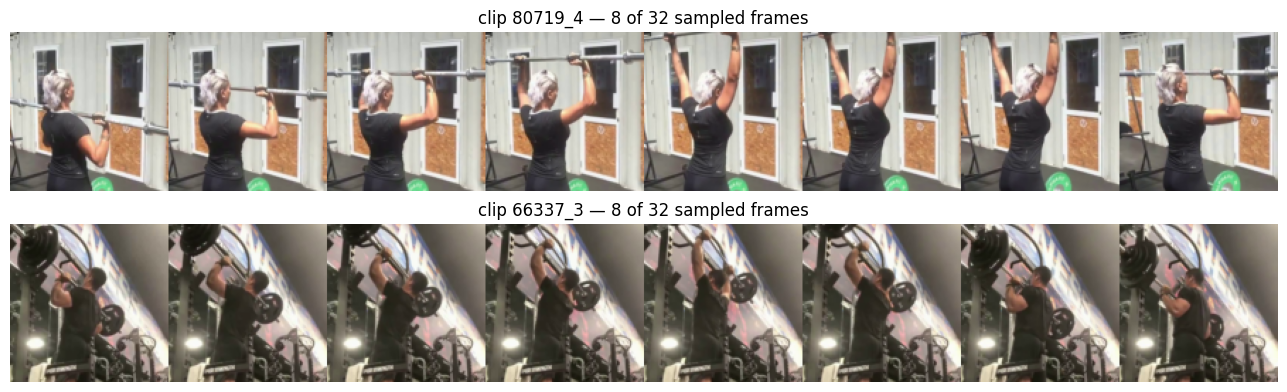

In [6]:
import zipfile, tempfile, os
try:
    zpath = Path(DRIVE_ROOT) / "Fitness-AQA_dataset_release/OHP/Labeled_Dataset/videos.zip"
    tmp = Path(tempfile.mkdtemp())
    ids = [recs["train"][0].clip_id, recs["train"][1].clip_id]
    with zipfile.ZipFile(zpath) as z:
        names = {Path(n).stem: n for n in z.namelist() if n.endswith(".mp4")}
        for cid in ids:
            with z.open(names[cid]) as src, open(tmp / f"{cid}.mp4", "wb") as dst:
                dst.write(src.read())
    mean = torch.tensor(transforms.KINETICS_MEAN).view(3, 1, 1)
    std = torch.tensor(transforms.KINETICS_STD).view(3, 1, 1)
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 1, figsize=(14, 4))
    for ax, cid in zip(axes, ids):
        n = transforms.count_frames(str(tmp / f"{cid}.mp4"))
        clip = transforms.spatial_val(transforms.decode_clip(str(tmp / f"{cid}.mp4"),
                                      transforms.uniform_sample_indices(n, 32)))
        fr = clip.permute(1, 0, 2, 3)[::4]
        fr = (fr * std + mean).clamp(0, 1)
        ax.imshow(torch.cat([fr[i] for i in range(fr.shape[0])], dim=2).permute(1, 2, 0).numpy())
        ax.set_title(f"clip {cid} — 8 of 32 sampled frames"); ax.axis("off")
    fig.tight_layout(); plt.show()
except Exception as e:
    print("decoded-sample skipped:", repr(e))